# 🗄️ Ejercicio Avanzado 4 — SQL nivel 2: comercialización de concentrados y sensores de planta
### Mina Cerro Kori (ficticia) · *Datos simulados*

## ¿Necesito instalar un programa de SQL? **NO** ✋
Este es el punto que confunde a todos al empezar:
- **SQLite ya viene dentro de Python** (`import sqlite3`). No se instala nada, no se crea cuenta, no hay contraseña, no hay servidor.
- Una base de datos SQLite es simplemente **un archivo** (como un Excel, pero que entiende SQL).
- Los comandos que aprendas aquí son los mismos de SQL Server, Oracle, MySQL o PostgreSQL que usan las mineras grandes.

## Lo que practicarás (cada consulta viene explicada línea por línea)
| Comando | Qué hace |
|---|---|
| `SELECT ... FROM` | elegir columnas de una tabla |
| `WHERE` | filtrar filas por condición |
| `ORDER BY` | ordenar resultados |
| `GROUP BY` + `SUM/AVG/COUNT` | resumir (como tabla dinámica) |
| `JOIN` | combinar dos tablas (como BUSCARV) |
| `CASE WHEN` ⭐ nuevo | crear condiciones tipo "si pasa esto → etiqueta tal" |
| `BETWEEN` ⭐ nuevo | filtrar rangos (fechas, valores) |
| `HAVING` ⭐ nuevo | filtrar los grupos ya resumidos |

**Los dos casos de uso reales:**
1. **Comercialización:** lotes de concentrado de oro vendidos a traders → ¿cuánto vale cada lote? ¿qué comprador conviene?
2. **Sensores en continuo:** 720 lecturas horarias de planta → detectar automáticamente cuándo el mineral pasó en malas condiciones.

## Paso 0 — Crear la base de datos (Python lo hace solo)
Leemos el Excel y lo convertimos en 3 tablas SQL. La función `sql()` nos deja escribir consultas y ver el resultado como tabla.

In [1]:
import pandas as pd
import sqlite3, tempfile, os

xls = "../data/10_comercializacion_sensores.xlsx"
lotes = pd.read_excel(xls, sheet_name="lotes_concentrado")
compradores = pd.read_excel(xls, sheet_name="compradores")
sensores = pd.read_excel(xls, sheet_name="sensores_planta")

db = os.path.join(tempfile.gettempdir(), "comercial_kori.db")
con = sqlite3.connect(db)
lotes.to_sql("lotes", con, if_exists="replace", index=False)
compradores.to_sql("compradores", con, if_exists="replace", index=False)
sensores.to_sql("sensores", con, if_exists="replace", index=False)

def sql(q):
    """Ejecuta la consulta SQL y muestra el resultado."""
    return pd.read_sql_query(q, con)

sql("SELECT name AS tablas_creadas FROM sqlite_master WHERE type='table'")

,tablas_creadas
0,lotes
1,compradores
2,sensores


---
# PARTE 1 · Comercialización de concentrados 💰

## Consulta 1 — Ver los datos (`SELECT` + `LIMIT`)
**Pregunta de negocio:** ¿qué información tengo de mis embarques?

Cómo se lee la consulta:
- `SELECT *` → "dame **todas** las columnas" (el `*` significa 'todo')
- `FROM lotes` → "de la tabla `lotes`"
- `LIMIT 5` → "solo las primeras 5 filas" (para espiar sin traer todo)

In [2]:
sql("SELECT * FROM lotes LIMIT 5")

,lote_id,fecha_embarque,comprador,peso_humedo_tms,humedad_pct,ley_au_g_t,ley_ag_g_t
0,LT-001,2026-02-01,TradeMet Asia,69.2,8.2,93.2,892
1,LT-002,2026-02-07,AurumTrade GmbH,60.1,9.4,59.0,720
2,LT-003,2026-02-13,AurumTrade GmbH,56.1,8.0,69.8,788
3,LT-004,2026-02-19,TradeMet Asia,65.1,8.5,81.3,778
4,LT-005,2026-02-25,TradeMet Asia,67.7,8.9,89.2,843


## Consulta 2 — Filtrar (`WHERE` + `ORDER BY`)
**Pregunta:** ¿qué lotes tienen ley alta (>80 g/t) y a quién se vendieron?

- `WHERE ley_au_g_t > 80` → deja pasar solo las filas que cumplen la condición
- `ORDER BY ley_au_g_t DESC` → ordena de mayor a menor (`DESC` = descendente)

In [3]:
sql("""
SELECT lote_id, fecha_embarque, comprador, ley_au_g_t
FROM lotes
WHERE ley_au_g_t > 80
ORDER BY ley_au_g_t DESC
""")

,lote_id,fecha_embarque,comprador,ley_au_g_t
0,LT-028,2026-07-13,Pacifico Metals,98.1
1,LT-023,2026-06-13,AurumTrade GmbH,94.0
2,LT-001,2026-02-01,TradeMet Asia,93.2
3,LT-005,2026-02-25,TradeMet Asia,89.2
4,LT-021,2026-06-01,Pacifico Metals,87.0
5,LT-027,2026-07-07,TradeMet Asia,86.9
6,LT-018,2026-05-14,AurumTrade GmbH,85.9
7,LT-004,2026-02-19,TradeMet Asia,81.3


## Consulta 3 — Rango de fechas (`BETWEEN`) ⭐
**Pregunta:** ¿qué embarcamos en marzo de 2026?

`BETWEEN '2026-03-01' AND '2026-03-31'` → equivale a "desde... hasta..." (incluye ambos extremos). Funciona con fechas y con números.

In [4]:
sql("""
SELECT lote_id, fecha_embarque, comprador, peso_humedo_tms
FROM lotes
WHERE fecha_embarque BETWEEN '2026-03-01' AND '2026-03-31'
ORDER BY fecha_embarque
""")

,lote_id,fecha_embarque,comprador,peso_humedo_tms
0,LT-006,2026-03-03,Pacifico Metals,59.6
1,LT-007,2026-03-09,TradeMet Asia,66.4
2,LT-008,2026-03-15,TradeMet Asia,70.3
3,LT-009,2026-03-21,Pacifico Metals,60.3
4,LT-010,2026-03-27,AurumTrade GmbH,55.5


## Consulta 4 — Resumen por comprador (`GROUP BY`)
**Pregunta:** ¿cuánto tonelaje y qué ley promedio le vendimos a cada trader?

- `GROUP BY comprador` → agrupa las filas por comprador (una fila de resultado por cada uno)
- `SUM(...)`, `AVG(...)`, `COUNT(*)` → operan **dentro de cada grupo**
- `AS` → le pone nombre bonito a la columna resultante

In [5]:
sql("""
SELECT comprador,
       COUNT(*)                    AS n_lotes,
       ROUND(SUM(peso_humedo_tms), 0) AS tms_total,
       ROUND(AVG(ley_au_g_t), 1)   AS ley_au_promedio
FROM lotes
GROUP BY comprador
ORDER BY tms_total DESC
""")

,comprador,n_lotes,tms_total,ley_au_promedio
0,TradeMet Asia,12,782.0,77.7
1,AurumTrade GmbH,11,657.0,73.5
2,Pacifico Metals,7,429.0,77.6


## Consulta 5 — Valorizar cada lote (`JOIN`) 💵
**Pregunta clave de comercialización:** ¿cuánto vale cada lote en US$?

La tabla `lotes` no tiene los términos comerciales — están en la tabla `compradores` (% pagable de Au y maquila). El `JOIN` las une por la columna en común:

- `JOIN compradores c ON l.comprador = c.comprador` → "empareja cada lote con los términos de su comprador"
- `l.` y `c.` son **apodos** (alias) de las tablas, para no escribir el nombre completo
- La fórmula simplificada del valor: `peso seco × ley × %pagable × precio − peso × maquila`
- Peso seco = peso húmedo × (1 − humedad/100) → **en comercialización siempre se paga sobre base seca**

In [6]:
PRECIO_AU = 108.0  # US$/g (~3350 US$/oz, supuesto simulado)

sql(f"""
SELECT l.lote_id, l.comprador,
       ROUND(l.peso_humedo_tms * (1 - l.humedad_pct/100.0), 1) AS peso_seco_tms,
       l.ley_au_g_t,
       ROUND( l.peso_humedo_tms * (1 - l.humedad_pct/100.0)
              * l.ley_au_g_t * (c.pago_au_pct/100.0) * {PRECIO_AU}
            - l.peso_humedo_tms * (1 - l.humedad_pct/100.0) * c.maquila_usd_t
            , 0) AS valor_lote_usd
FROM lotes l
JOIN compradores c ON l.comprador = c.comprador
ORDER BY valor_lote_usd DESC
LIMIT 8
""")

,lote_id,comprador,peso_seco_tms,ley_au_g_t,valor_lote_usd
0,LT-028,Pacifico Metals,62.2,98.1,626072.0
1,LT-001,TradeMet Asia,63.5,93.2,605609.0
2,LT-021,Pacifico Metals,67.8,87.0,603376.0
3,LT-023,AurumTrade GmbH,62.3,94.0,590661.0
4,LT-005,TradeMet Asia,61.7,89.2,562253.0
5,LT-027,TradeMet Asia,61.5,86.9,545750.0
6,LT-008,TradeMet Asia,64.4,77.7,509871.0
7,LT-013,AurumTrade GmbH,64.9,77.8,507526.0


## Consulta 6 — ¿Qué comprador nos conviene? (`JOIN` + `GROUP BY` + `HAVING`) ⭐
`HAVING` es como `WHERE` pero **después** de agrupar: filtra grupos, no filas.
Aquí: "muéstrame solo compradores a los que les vendimos más de 5 lotes".

In [7]:
PRECIO_AU = 108.0
sql(f"""
SELECT c.comprador, c.pais, c.pago_au_pct, c.maquila_usd_t,
       COUNT(*) AS n_lotes,
       ROUND(AVG( l.peso_humedo_tms * (1 - l.humedad_pct/100.0)
                  * l.ley_au_g_t * (c.pago_au_pct/100.0) * {PRECIO_AU}
                - l.peso_humedo_tms * (1 - l.humedad_pct/100.0) * c.maquila_usd_t
            ) / AVG(l.peso_humedo_tms * (1 - l.humedad_pct/100.0)), 0) AS usd_por_tms
FROM lotes l
JOIN compradores c ON l.comprador = c.comprador
GROUP BY c.comprador
HAVING COUNT(*) > 5
ORDER BY usd_por_tms DESC
""")

,comprador,pais,pago_au_pct,maquila_usd_t,n_lotes,usd_por_tms
0,Pacifico Metals,Chile,97.0,210,7,8035.0
1,TradeMet Asia,Singapur,96.5,180,12,7942.0
2,AurumTrade GmbH,Alemania,95.0,165,11,7446.0


> 💡 **Lectura comercial:** el mejor comprador no es el de mayor % pagable a secas — hay que ver el **neto por tonelada seca** (pagable − maquila). Esta consulta lo responde en una sola tabla.

---
# PARTE 2 · Sensores en continuo 🌡️
720 lecturas horarias (30 días) de pH, densidad, flujo y ley online. El objetivo: que la base de datos **detecte sola** cuándo el mineral pasó en malas condiciones.

In [8]:
sql("SELECT * FROM sensores LIMIT 5")

,fecha_hora,ph_pulpa,densidad_pulpa_kg_l,flujo_alimento_m3_h,ley_au_online_g_t
0,2026-03-01 00:00,10.48,1.393,182.5,4.38
1,2026-03-01 01:00,10.78,1.367,205.5,3.64
2,2026-03-01 02:00,10.60,1.487,230.8,4.11
3,2026-03-01 03:00,10.17,1.348,226.1,5.27
4,2026-03-01 04:00,10.15,1.393,184.2,4.06


## Consulta 7 — Detectar condiciones anormales (`CASE WHEN`) ⭐
`CASE WHEN` crea una columna nueva según condiciones — es el "SI() de Excel" en SQL:

```sql
CASE WHEN condición THEN 'etiqueta A'
     WHEN otra_condición THEN 'etiqueta B'
     ELSE 'etiqueta normal' END
```
**Regla de planta (simulada):** pH ideal 10.0–11.0 (protege la flotación) y flujo mínimo 150 m³/h.

In [9]:
sql("""
SELECT fecha_hora, ph_pulpa, flujo_alimento_m3_h,
       CASE
         WHEN ph_pulpa < 10.0            THEN '⚠ pH BAJO: riesgo en flotación'
         WHEN flujo_alimento_m3_h < 150  THEN '⚠ FLUJO BAJO: posible atoro'
         ELSE 'Normal'
       END AS condicion
FROM sensores
WHERE ph_pulpa < 10.0 OR flujo_alimento_m3_h < 150
ORDER BY fecha_hora
LIMIT 12
""")

,fecha_hora,ph_pulpa,flujo_alimento_m3_h,condicion
0,2026-03-01 16:00,9.87,231.0,⚠ pH BAJO: riesgo en flotación
1,2026-03-02 08:00,9.93,179.2,⚠ pH BAJO: riesgo en flotación
2,2026-03-02 20:00,9.99,225.7,⚠ pH BAJO: riesgo en flotación
3,2026-03-02 22:00,9.86,203.5,⚠ pH BAJO: riesgo en flotación
4,2026-03-03 00:00,9.87,190.8,⚠ pH BAJO: riesgo en flotación
5,2026-03-03 03:00,9.89,209.1,⚠ pH BAJO: riesgo en flotación
6,2026-03-04 01:00,9.59,195.5,⚠ pH BAJO: riesgo en flotación
7,2026-03-04 05:00,9.88,213.3,⚠ pH BAJO: riesgo en flotación
8,2026-03-04 06:00,9.87,202.1,⚠ pH BAJO: riesgo en flotación
9,2026-03-04 13:00,9.73,201.1,⚠ pH BAJO: riesgo en flotación


## Consulta 8 — ¿Cuántas horas estuvo mal cada día? (`GROUP BY` sobre fechas)
`substr(fecha_hora, 1, 10)` corta el texto y se queda con la fecha (posiciones 1 a 10: `2026-03-09`). Así agrupamos las 24 lecturas de cada día.

In [10]:
alertas_dia = sql("""
SELECT substr(fecha_hora, 1, 10) AS dia,
       SUM(CASE WHEN ph_pulpa < 10.0 THEN 1 ELSE 0 END)           AS horas_ph_bajo,
       SUM(CASE WHEN flujo_alimento_m3_h < 150 THEN 1 ELSE 0 END) AS horas_flujo_bajo,
       ROUND(AVG(ley_au_online_g_t), 2)                           AS ley_promedio_dia
FROM sensores
GROUP BY dia
HAVING horas_ph_bajo > 0 OR horas_flujo_bajo > 0
ORDER BY dia
""")
alertas_dia

,dia,horas_ph_bajo,horas_flujo_bajo,ley_promedio_dia
0,2026-03-01,1,0,4.56
1,2026-03-02,3,0,4.59
2,2026-03-03,2,0,4.67
3,2026-03-04,5,0,4.96
4,2026-03-05,3,0,4.51
5,2026-03-06,1,0,4.57
6,2026-03-07,4,0,4.79
7,2026-03-08,1,0,4.60
8,2026-03-09,4,15,4.80
9,2026-03-10,2,0,4.74


> 🔍 La base de datos encontró sola los 2 eventos que hubo en el mes: un **atoro** (flujo bajo) y una **caída de pH** de ~30 horas. En una planta real esta misma consulta corre automática cada hora y dispara alertas.

## Consulta 9 — Visualizar el evento de pH

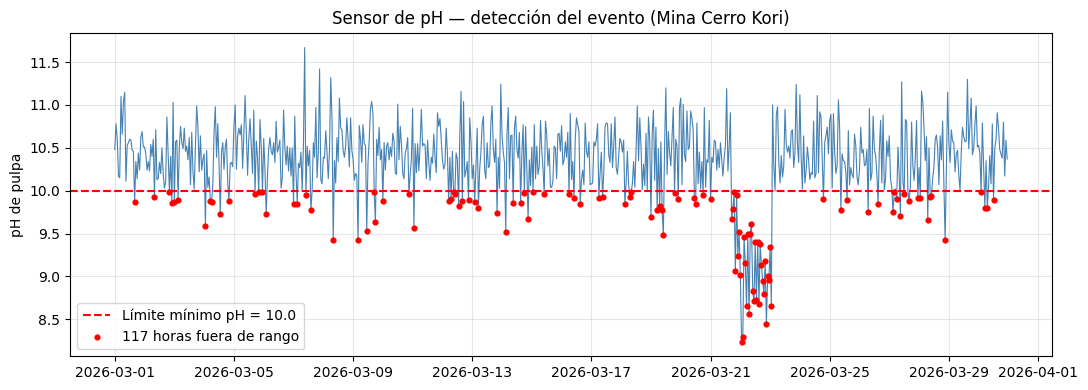

In [11]:
import matplotlib.pyplot as plt

df = sql("SELECT fecha_hora, ph_pulpa FROM sensores")
df["fecha_hora"] = pd.to_datetime(df["fecha_hora"])

plt.figure(figsize=(11, 4))
plt.plot(df["fecha_hora"], df["ph_pulpa"], lw=0.8, color="steelblue")
plt.axhline(10.0, color="red", ls="--", label="Límite mínimo pH = 10.0")
bajo = df[df["ph_pulpa"] < 10.0]
plt.scatter(bajo["fecha_hora"], bajo["ph_pulpa"], color="red", s=12, zorder=3,
            label=f"{len(bajo)} horas fuera de rango")
plt.ylabel("pH de pulpa"); plt.title("Sensor de pH — detección del evento (Mina Cerro Kori)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

con.close()

## ✅ Lo que aprendiste hoy
1. **No necesitas instalar nada** para practicar SQL: SQLite vive dentro de Python.
2. `JOIN` + `GROUP BY` responden la pregunta comercial clave: *¿qué comprador paga mejor por tonelada seca?*
3. `CASE WHEN` convierte reglas operativas ("pH < 10 es malo") en columnas de alerta automáticas.
4. Con `substr` + `GROUP BY` pasas de 720 lecturas horarias a un resumen diario de eventos.

**Reto para ti** (modifica las consultas):
- Cambia el límite de pH a 10.2 → ¿cuántas horas de alerta salen ahora?
- En la consulta 6, ¿qué pasa si la maquila de TradeMet sube a 220 US$/t?
- Agrega a la consulta 8 una columna de densidad promedio por día.

**Anterior:** [SQL desde cero](07_avanzado_sql_planta.ipynb) · **Volver al** [README](../README.md)